In [48]:
import numpy as np
import matplotlib.pyplot as plt

from field_lines import PeriodicInterpolator, integrate_lines, unwrap_lines, plot_field_lines
from generate_kolmogorov import get_field_cube, set_cubes

In [49]:
L = 300  # [pc], half-size
n_side = 256
dx = 2*L/n_side
print(f"Each cell is a cube with size {dx:.2f} pc")

r_cube, _ = set_cubes(n_side, L)

Each cell is a cube with size 2.34 pc


In [50]:
b_cube = get_field_cube(n_side, L, power_index=11/3)  # normalized isotropic field

## 0.1 turbulent / regular ratio

$$ B = \sqrt{B_0^2 + \langle{\delta B^2}\rangle} = B_0^2 \sqrt{1 + \delta^2}$$

In [75]:
delta = 0.1

b0 = 1 / np.sqrt(1 + delta**2)

b_turb = delta / np.sqrt(1 + delta**2) * b_cube

b_cube_01 = b_turb
b_cube_01[2] += b0

In [76]:
periodic_interpolator = PeriodicInterpolator(r_cube, b_cube_01)

In [77]:
M = 400
ds = dx / 5
n_steps = int(L / ds)  # n_steps

lines = integrate_lines(periodic_interpolator, M, n_steps, ds)
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

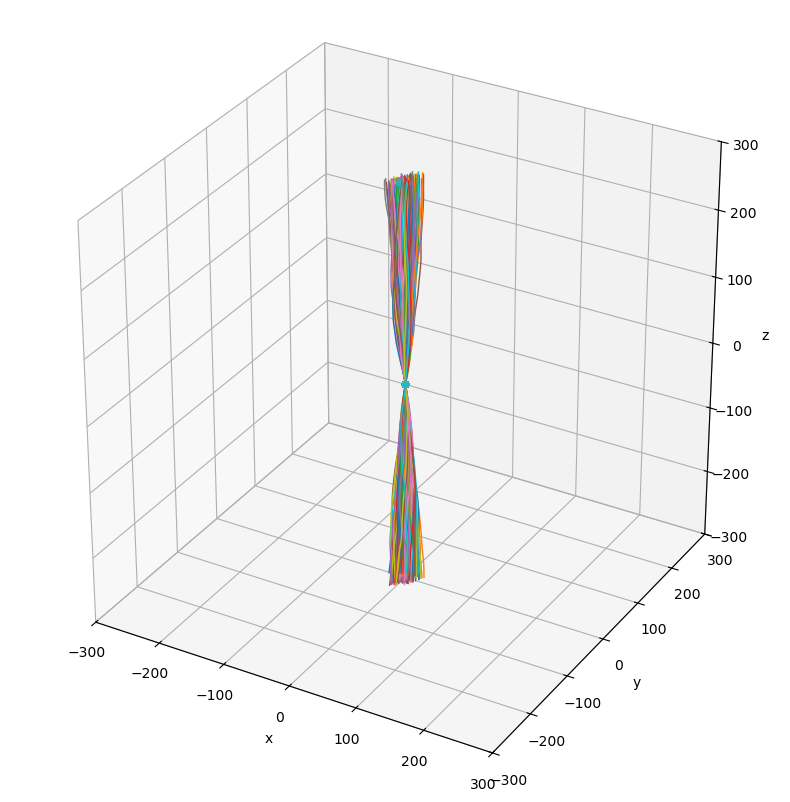

In [78]:
plot_field_lines(
    lines_from_zero,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

In [79]:
lengths = np.sqrt(np.sum(lines_from_zero**2, axis=2)) + 1e-32
cos01 = lines_from_zero[..., 2] / lengths

cos01_avg = np.average(cos01, axis=0)
cos01_std = np.std(np.abs(cos01), axis=0)

In [80]:
x = np.linspace(1, M, M)

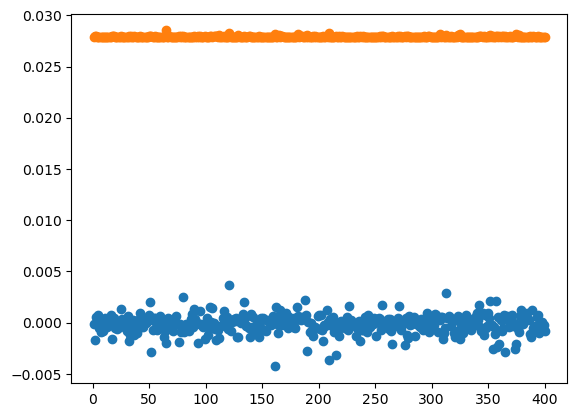

In [81]:
plt.scatter(x, cos01_avg)
plt.scatter(x, cos01_std)
plt.show()

## 0.5 turbulent / regular ratio

In [96]:
delta = 0.5

b0 = 1 / np.sqrt(1 + delta**2)

b_turb = delta / np.sqrt(1 + delta**2) * b_cube

b_cube_05 = b_turb
b_cube_05[2] += b0

In [97]:
periodic_interpolator = PeriodicInterpolator(r_cube, b_cube_05)

In [98]:
lines = integrate_lines(periodic_interpolator, M, n_steps, ds)
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

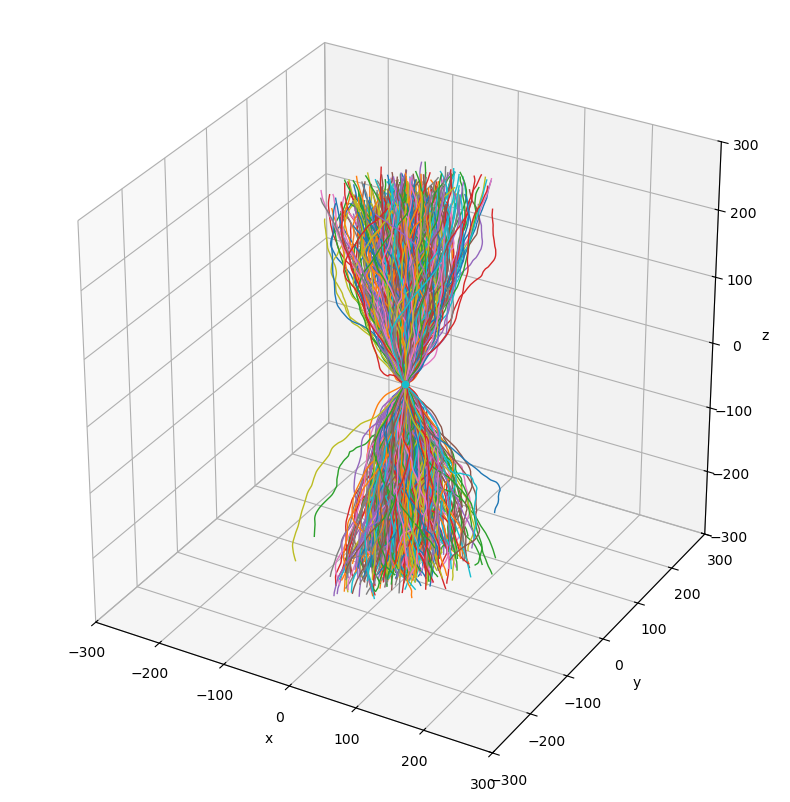

In [99]:
plot_field_lines(
    lines_from_zero,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

In [100]:
lengths = np.sqrt(np.sum(lines_from_zero**2, axis=2)) + 1e-32
cos05 = lines_from_zero[..., 2] / lengths

cos05_avg = np.average(cos05, axis=0)
cos05_std = np.std(np.abs(cos05), axis=0)

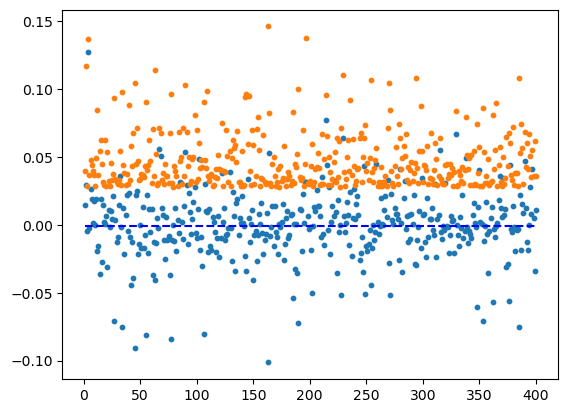

In [101]:
plt.scatter(x, cos05_avg, s=10)
plt.plot(x, np.ones_like(x) * np.mean(cos05_avg), color='blue', linestyle='dashed')
plt.scatter(x, cos05_std, s=10)
plt.show()

## 1.0 turbulent / regular ratio

In [102]:
delta = 1.0

b0 = 1 / np.sqrt(1 + delta**2)

b_turb = delta / np.sqrt(1 + delta**2) * b_cube

b_cube_10 = b_turb
b_cube_10[2] += b0

In [103]:
periodic_interpolator = PeriodicInterpolator(r_cube, b_cube_10)

In [104]:
lines = integrate_lines(periodic_interpolator, M, n_steps, ds)
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

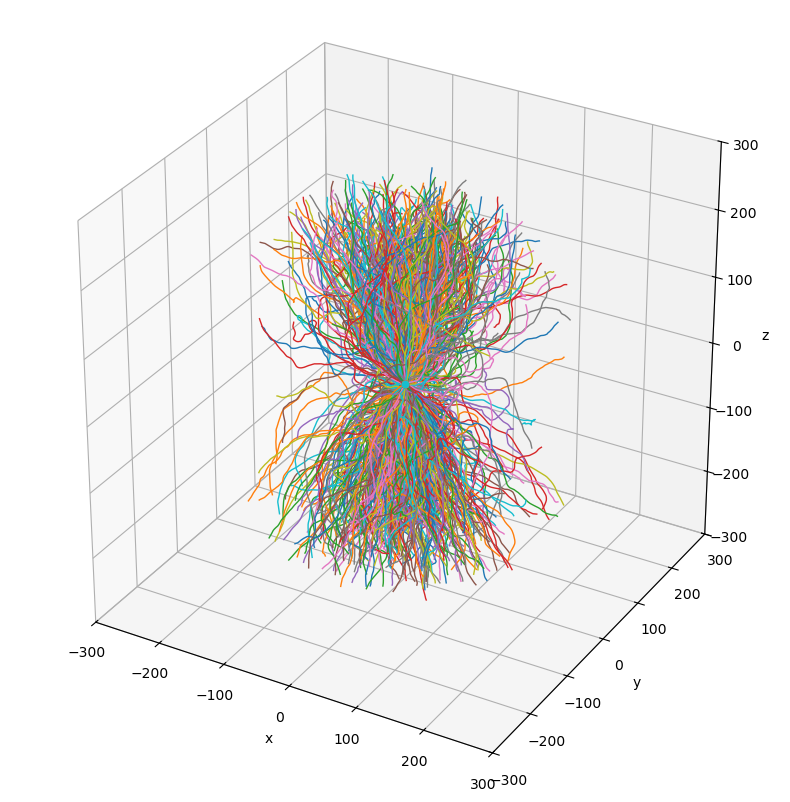

In [105]:
plot_field_lines(
    lines_from_zero,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

In [108]:
lengths = np.sqrt(np.sum(lines_from_zero**2, axis=2)) + 1e-32
cos10 = lines_from_zero[..., 2] / lengths

cos10_avg = np.average(cos10, axis=0)
cos10_std = np.std(np.abs(cos10), axis=0)

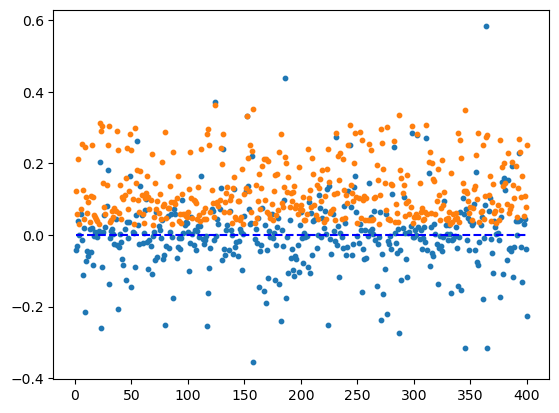

In [109]:
plt.scatter(x, cos10_avg, s=10)
plt.plot(x, np.ones_like(x) * np.mean(cos10_avg), color='blue', linestyle='dashed')
plt.scatter(x, cos10_std, s=10)
plt.show()